<div align="center">

# Adult Income Classification Using Machine Learning

### CCS23213 – Data Mining

### Real-World Data Mining Project

---

### Group Project

**Course:** CCS23213 Data Mining

**Dataset:** Adult Income Dataset (UCI Machine Learning Repository)

**Task Type:** Classification

**Target Variable:** Income

**Algorithms:** Decision Tree · Naïve Bayes  

**Train-Test Splits:** 50:50 · 60:40 · 70:30 · 80:20 · 90:10

**Objective:** Predict whether an individual's annual income exceeds \$50,000 based on demographic and census-related attributes.

---

### Group Members

| Name | Student ID |
|--------|--------|
| Abdou Salam Sisawo | AIU24102271 |
| Anas Muhammad Sani Lawal | XXXXXXX |
| Zikrullah Faizan | XXXXXXX |

---

### Lecturer

Dr./Mr./Ms. __________________

---

### Submission Date

18 June 2026

# 1. Project Background

## 1.1 Dataset Overview

This project utilizes the **Adult Income Dataset**, also known as the **Census Income Dataset**, obtained from the UCI Machine Learning Repository. The dataset was originally extracted by Barry Becker from the 1994 United States Census Database and has become one of the most widely used benchmark datasets for classification problems in machine learning and data mining.

The objective of the dataset is to predict whether an individual's annual income exceeds **$50,000 per year** based on demographic, educational, occupational, and financial attributes.

### Dataset Source

* Source: UCI Machine Learning Repository
* Dataset Name: Adult (Census Income)
* URL: https://archive.ics.uci.edu/dataset/2/adult
* Donated: April 30, 1996
* Creators: Barry Becker and Ron Kohavi

### Dataset Characteristics

| Attribute          | Value                     |
| ------------------ | ------------------------- |
| Dataset Type       | Multivariate              |
| Data Mining Task   | Classification            |
| Number of Records  | 48,842                    |
| Number of Features | 14                        |
| Target Variable    | Income                    |
| Missing Values     | Yes                       |
| Feature Types      | Numerical and Categorical |

### Problem Statement

Income prediction is an important problem in socioeconomic analysis. Governments, researchers, and organizations frequently analyze demographic and occupational factors to understand income distribution patterns and support data-driven decision-making.

The problem addressed in this project is to determine whether an individual's annual income exceeds $50,000 based on information such as age, education, occupation, work class, working hours, and other demographic characteristics.

### Objective of the Study

The main objective of this project is to develop and evaluate machine learning classification models capable of accurately predicting whether an individual's annual income exceeds $50,000 per year.

### Data Mining Task

This project involves a **Classification** task because the target variable consists of two predefined categories:

* Income ≤ $50K
* Income > $50K

---

## 1.2 Dataset Attribute Description

The Adult Income Dataset contains 14 predictor variables and 1 target variable. The measurement scale and data type of each attribute are summarized below.

| Feature        | Description                     | Data Type   | Measurement Scale | Variable Nature |
| -------------- | ------------------------------- | ----------- | ----------------- | --------------- |
| age            | Age of individual               | Numerical   | Ratio             | Continuous      |
| workclass      | Employment category             | Categorical | Nominal           | Discrete        |
| fnlwgt         | Census final weight             | Numerical   | Ratio             | Continuous      |
| education      | Highest education level         | Categorical | Ordinal           | Discrete        |
| education-num  | Education level in numeric form | Numerical   | Ordinal           | Discrete        |
| marital-status | Marital status                  | Categorical | Nominal           | Discrete        |
| occupation     | Occupation type                 | Categorical | Nominal           | Discrete        |
| relationship   | Family relationship status      | Categorical | Nominal           | Discrete        |
| race           | Race category                   | Categorical | Nominal           | Discrete        |
| sex            | Gender                          | Categorical | Nominal           | Discrete        |
| capital-gain   | Capital gain amount             | Numerical   | Ratio             | Continuous      |
| capital-loss   | Capital loss amount             | Numerical   | Ratio             | Continuous      |
| hours-per-week | Weekly working hours            | Numerical   | Ratio             | Continuous      |
| native-country | Country of origin               | Categorical | Nominal           | Discrete        |
| income         | Annual income category (Target) | Categorical | Nominal           | Discrete        |

---

## 1.3 Machine Learning Workflow

The project follows the standard data mining and machine learning lifecycle:

1. Data Collection and Integration
2. Data Understanding
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering
6. Train-Test Split Experiments
7. Model Development
8. Model Evaluation
9. Model Comparison
10. Model Validation Using Unseen Data
11. Model Export and Deployment Preparation

Two classification algorithms will be developed and evaluated using five train-test split ratios (50:50, 60:40, 70:30, 80:20, and 90:10). The best-performing model will be selected based on Accuracy, Precision, Recall, and F1-Score.


## 2. Importing Libraries and Dependancies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42

## 3. Dataset Loading and Integration

In [2]:
COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

train_raw = pd.read_csv(
    'adult.data', names=COLUMNS, sep=', ', engine='python', na_values='?'
)
test_raw = pd.read_csv(
    'adult.test', names=COLUMNS, sep=', ', engine='python', na_values='?', skiprows=1
)
test_raw['income'] = test_raw['income'].str.replace('.', '', regex=False)

df = pd.concat([train_raw, test_raw], ignore_index=True)

print(f"Combined dataset shape: {df.shape}")
print(f"  Training records : {len(train_raw):,}")
print(f"  Test records     : {len(test_raw):,}")
print(f"  Total records    : {len(df):,}")
print(f"  Attributes       : {df.shape[1]}")


Combined dataset shape: (48842, 15)
  Training records : 32,561
  Test records     : 16,281
  Total records    : 48,842
  Attributes       : 15


In [3]:
# Dataset Overview
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 4. Exploratory Data Analysis

In [4]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [5]:
print("Statistical Summary — Continuous Features only:")
df.describe().round(2)

Statistical Summary — Continuous Features only:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


In [6]:
# Statistical Summary — All Features
print("Statistical Summary — All Features")
df.describe(include='all').round(2)

Statistical Summary — All Features


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.00,46043,48842.00,48842,48842.00,48842,46033,48842,48842,48842,48842.00,48842.0,48842.00,47985,48842
unique,NaN,8,NaN,16,NaN,7,14,6,5,2,NaN,NaN,NaN,41,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,37155
mean,38.64,NaN,189664.13,NaN,10.08,NaN,NaN,NaN,NaN,NaN,1079.07,87.5,40.42,NaN,NaN
std,13.71,NaN,105604.03,NaN,2.57,NaN,NaN,NaN,NaN,NaN,7452.02,403.0,12.39,NaN,NaN
min,17.00,NaN,12285.00,NaN,1.00,NaN,NaN,NaN,NaN,NaN,0.00,0.0,1.00,NaN,NaN
25%,28.00,NaN,117550.50,NaN,9.00,NaN,NaN,NaN,NaN,NaN,0.00,0.0,40.00,NaN,NaN
50%,37.00,NaN,178144.50,NaN,10.00,NaN,NaN,NaN,NaN,NaN,0.00,0.0,40.00,NaN,NaN
75%,48.00,NaN,237642.00,NaN,12.00,NaN,NaN,NaN,NaN,NaN,0.00,0.0,45.00,NaN,NaN


In [7]:
# Missing Values Analysis
print("Missing Values per Column:")
df.isnull().sum()

Missing Values per Column:


age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

In [8]:
# Unique Value Counts for Categorical Features
categorical_cols = df.select_dtypes(include=['object']).columns
print("Unique Value Counts for Categorical Features:")
for col in categorical_cols:
    print(f"Unique values in {col}: {df[col].nunique()}")

Unique Value Counts for Categorical Features:
Unique values in workclass: 8
Unique values in education: 16
Unique values in marital-status: 7
Unique values in occupation: 14
Unique values in relationship: 6
Unique values in race: 5
Unique values in sex: 2
Unique values in native-country: 41
Unique values in income: 2


In [9]:
# checking for duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 52


#### -- Target Class Distribution

Income Class Distribution:
  <=50K    : 37,155  (76.07%)
  >50K     : 11,687  (23.93%)


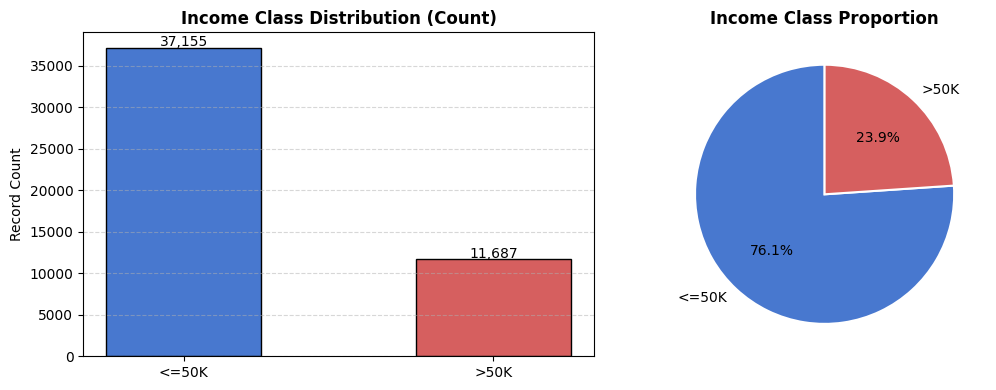

In [10]:
# Class Distribution Analysis
class_counts = df['income'].value_counts()
class_pct    = (class_counts / len(df) * 100).round(2)

print("Income Class Distribution:")
for cls, cnt, pct in zip(class_counts.index, class_counts.values, class_pct.values):
    print(f"  {cls:<8} : {cnt:>6,}  ({pct:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ['#4878CF', '#D65F5F']
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Income Class Distribution (Count)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Record Count')
for i, (cls, cnt) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, cnt + 200, f'{cnt:,}', ha='center', fontsize=10)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Income Class Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### -- Missing Value Distribution

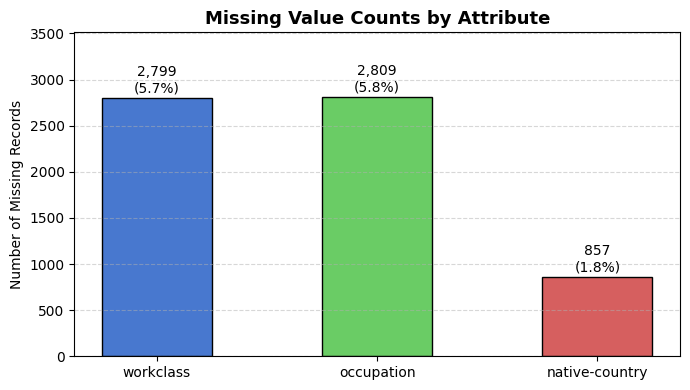

In [11]:
# Missing Values  distribution Analysis
fig, ax = plt.subplots(figsize=(7, 4))
cols_miss = ['workclass', 'occupation', 'native-country']
counts = [df[c].isnull().sum() for c in cols_miss]
bars = ax.bar(cols_miss, counts, color=['#4878CF', '#6ACC65', '#D65F5F'], edgecolor='black', width=0.5)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{cnt:,}\n({cnt/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Missing Value Counts by Attribute', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Missing Records')
ax.set_ylim(0, max(counts) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


#### -- Outlier Detection

In [12]:
# Outlier Analysis using IQR method
cont_features = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

print("Outlier Analysis (IQR Method):")
print(f"{'Feature':<18} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'%':>6}")
print("-" * 85)

outlier_summary = {}
for col in cont_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    outlier_summary[col] = {'lower': lower, 'upper': upper, 'n': n_out, 'pct': pct}
    print(f"{col:<18} {Q1:>8.1f} {Q3:>8.1f} {IQR:>8.1f} {lower:>10.1f} {upper:>10.1f} {n_out:>10,} {pct:>5.1f}%")


Outlier Analysis (IQR Method):
Feature                  Q1       Q3      IQR      Lower      Upper   Outliers      %
-------------------------------------------------------------------------------------
age                    28.0     48.0     20.0       -2.0       78.0        216   0.4%
education-num           9.0     12.0      3.0        4.5       16.5      1,794   3.7%
capital-gain            0.0      0.0      0.0        0.0        0.0      4,035   8.3%
capital-loss            0.0      0.0      0.0        0.0        0.0      2,282   4.7%
hours-per-week         40.0     45.0      5.0       32.5       52.5     13,496  27.6%


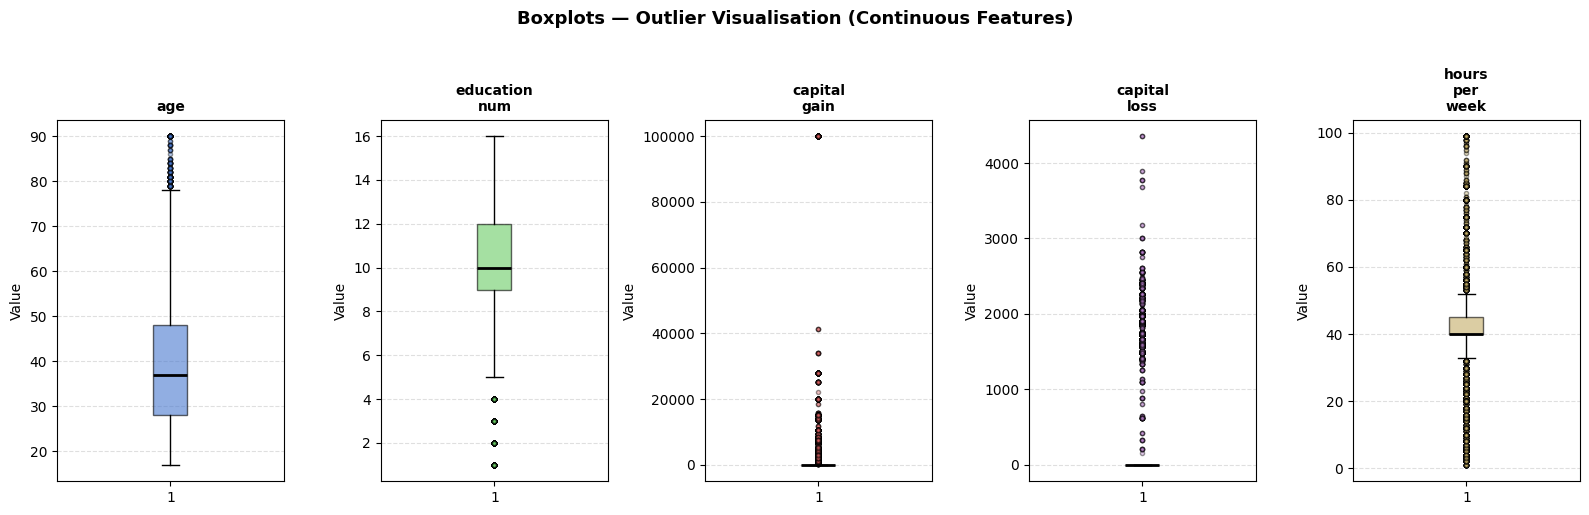

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
palette = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']

for ax, col, color in zip(axes, cont_features, palette):
    bp = ax.boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor=color, markersize=3, alpha=0.4))
    ax.set_title(col.replace('-', '\n'), fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Boxplots — Outlier Visualisation (Continuous Features)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#### -- Continous Features Visualization

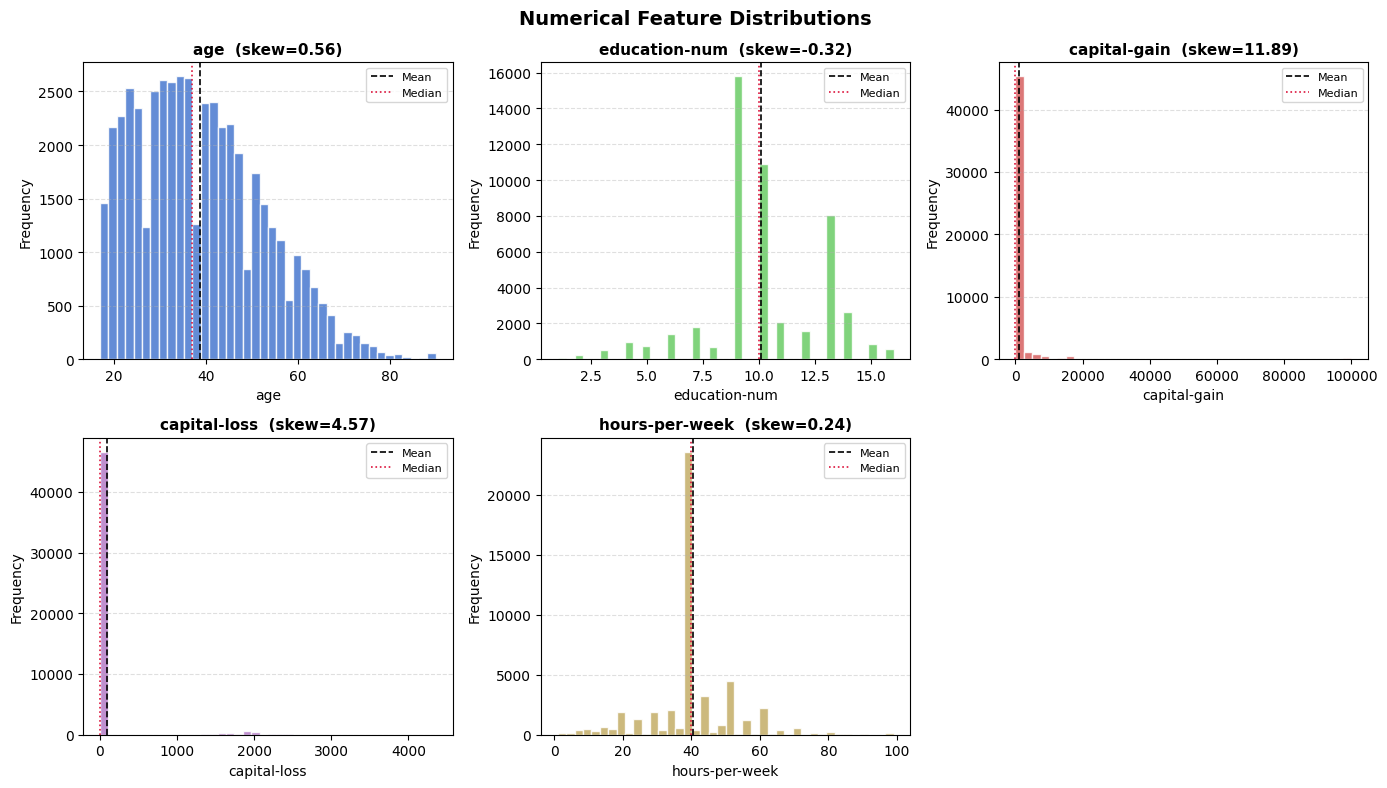

In [14]:
# Visualise distributions of continuous features with histograms, showing mean and median lines.
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
palette = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']

for ax, col, color in zip(axes, cont_features, palette):
    skew_val = df[col].skew()
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='black',  linestyle='--', linewidth=1.2, label='Mean')
    ax.axvline(df[col].median(), color='crimson', linestyle=':',  linewidth=1.2, label='Median')
    ax.set_title(f'{col}  (skew={skew_val:.2f})', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.delaxes(axes[5])
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


#### -- Categorical Feature Distributions

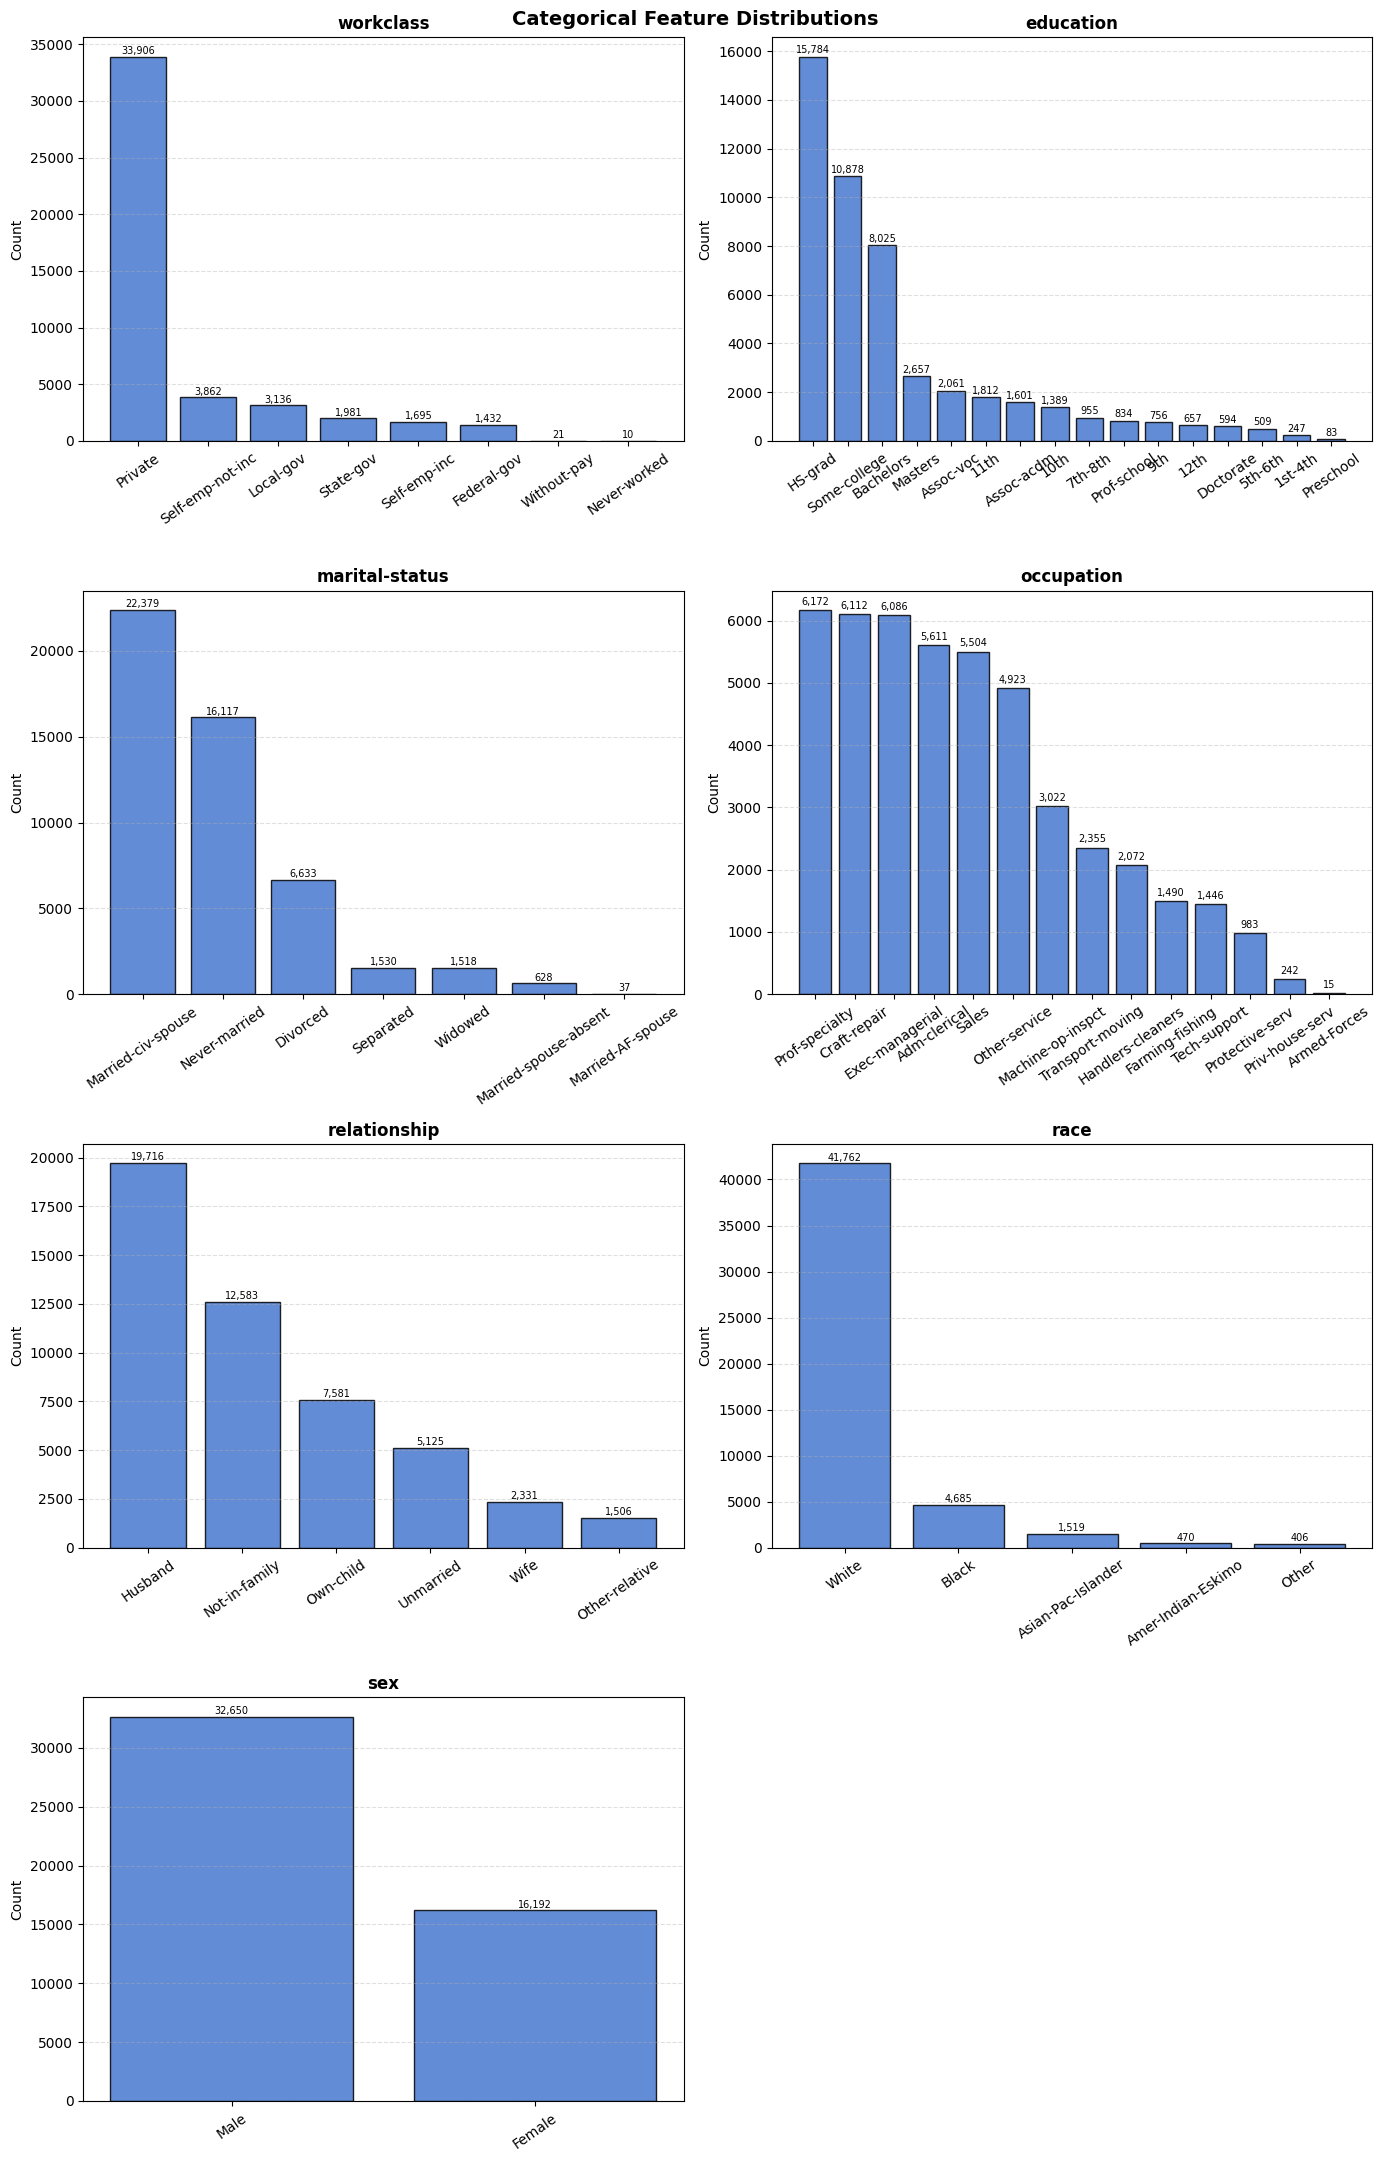

In [15]:
# Visualise distributions of categorical features with bar plots.
cat_features = ['workclass', 'education', 'marital-status',
                'occupation', 'relationship', 'race', 'sex']

fig, axes = plt.subplots(4, 2, figsize=(14, 22))
axes = axes.flatten()

for ax, col in zip(axes, cat_features):
    vc = df[col].value_counts()
    bars = ax.bar(vc.index, vc.values, color='#4878CF', edgecolor='black', alpha=0.85)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', va='bottom', fontsize=7)

fig.delaxes(axes[-1])
plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### -- Distribution of continous features by Income Class

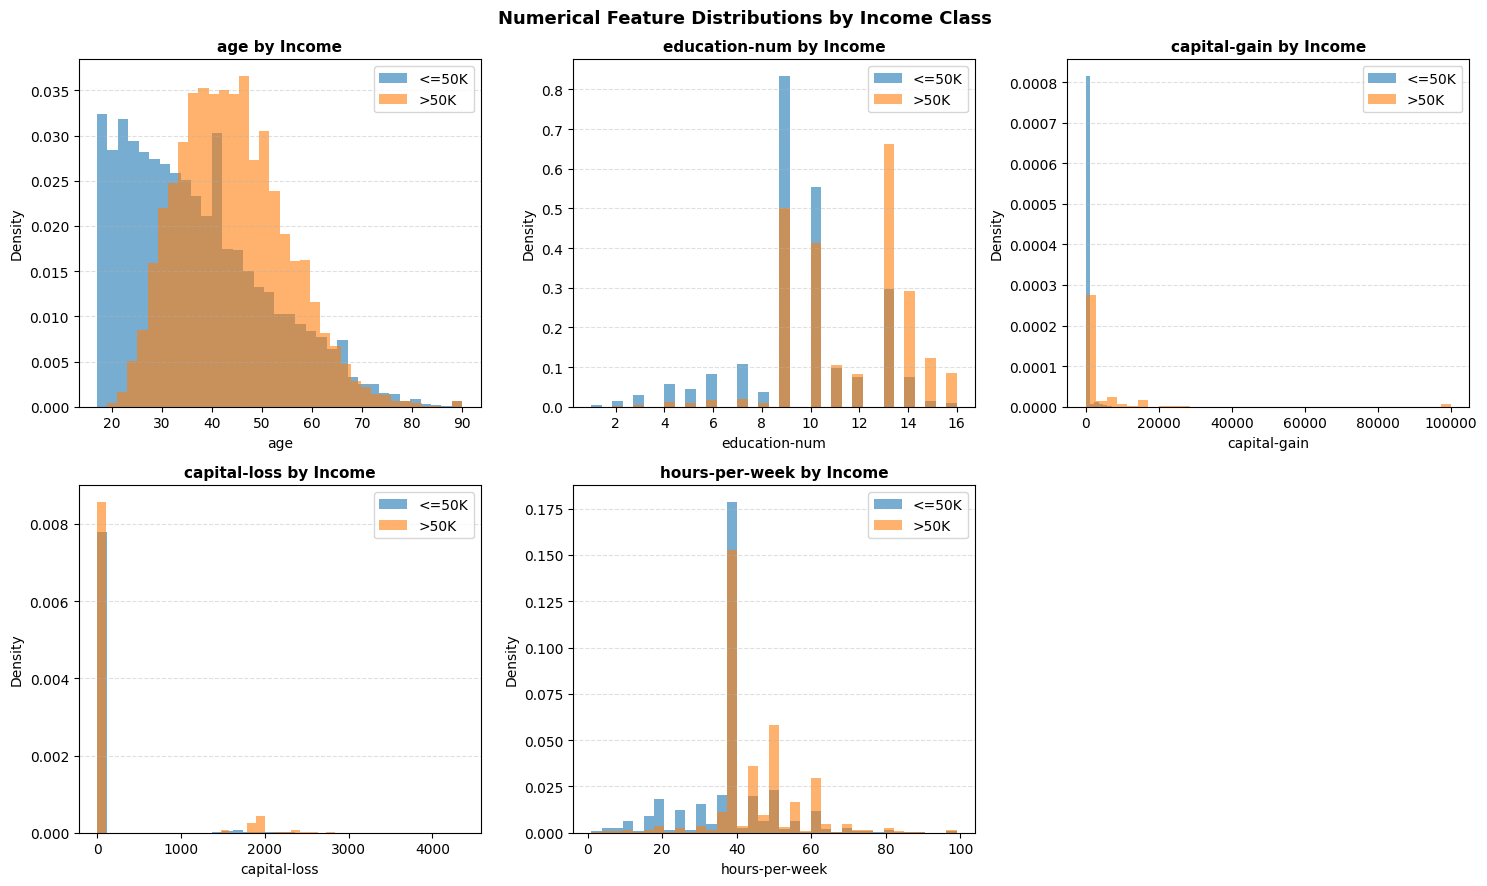

In [16]:
# Visualise distributions of continuous features by income class with overlaid histograms.
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col, color in zip(axes, cont_features, palette):
    for label, grp in df.groupby('income')[col]:
        ax.hist(grp, bins=35, alpha=0.6, label=label, edgecolor='none', density=True)
    ax.set_title(f'{col} by Income', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.delaxes(axes[5])
plt.suptitle('Numerical Feature Distributions by Income Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### -- Categorical Features vs Income 

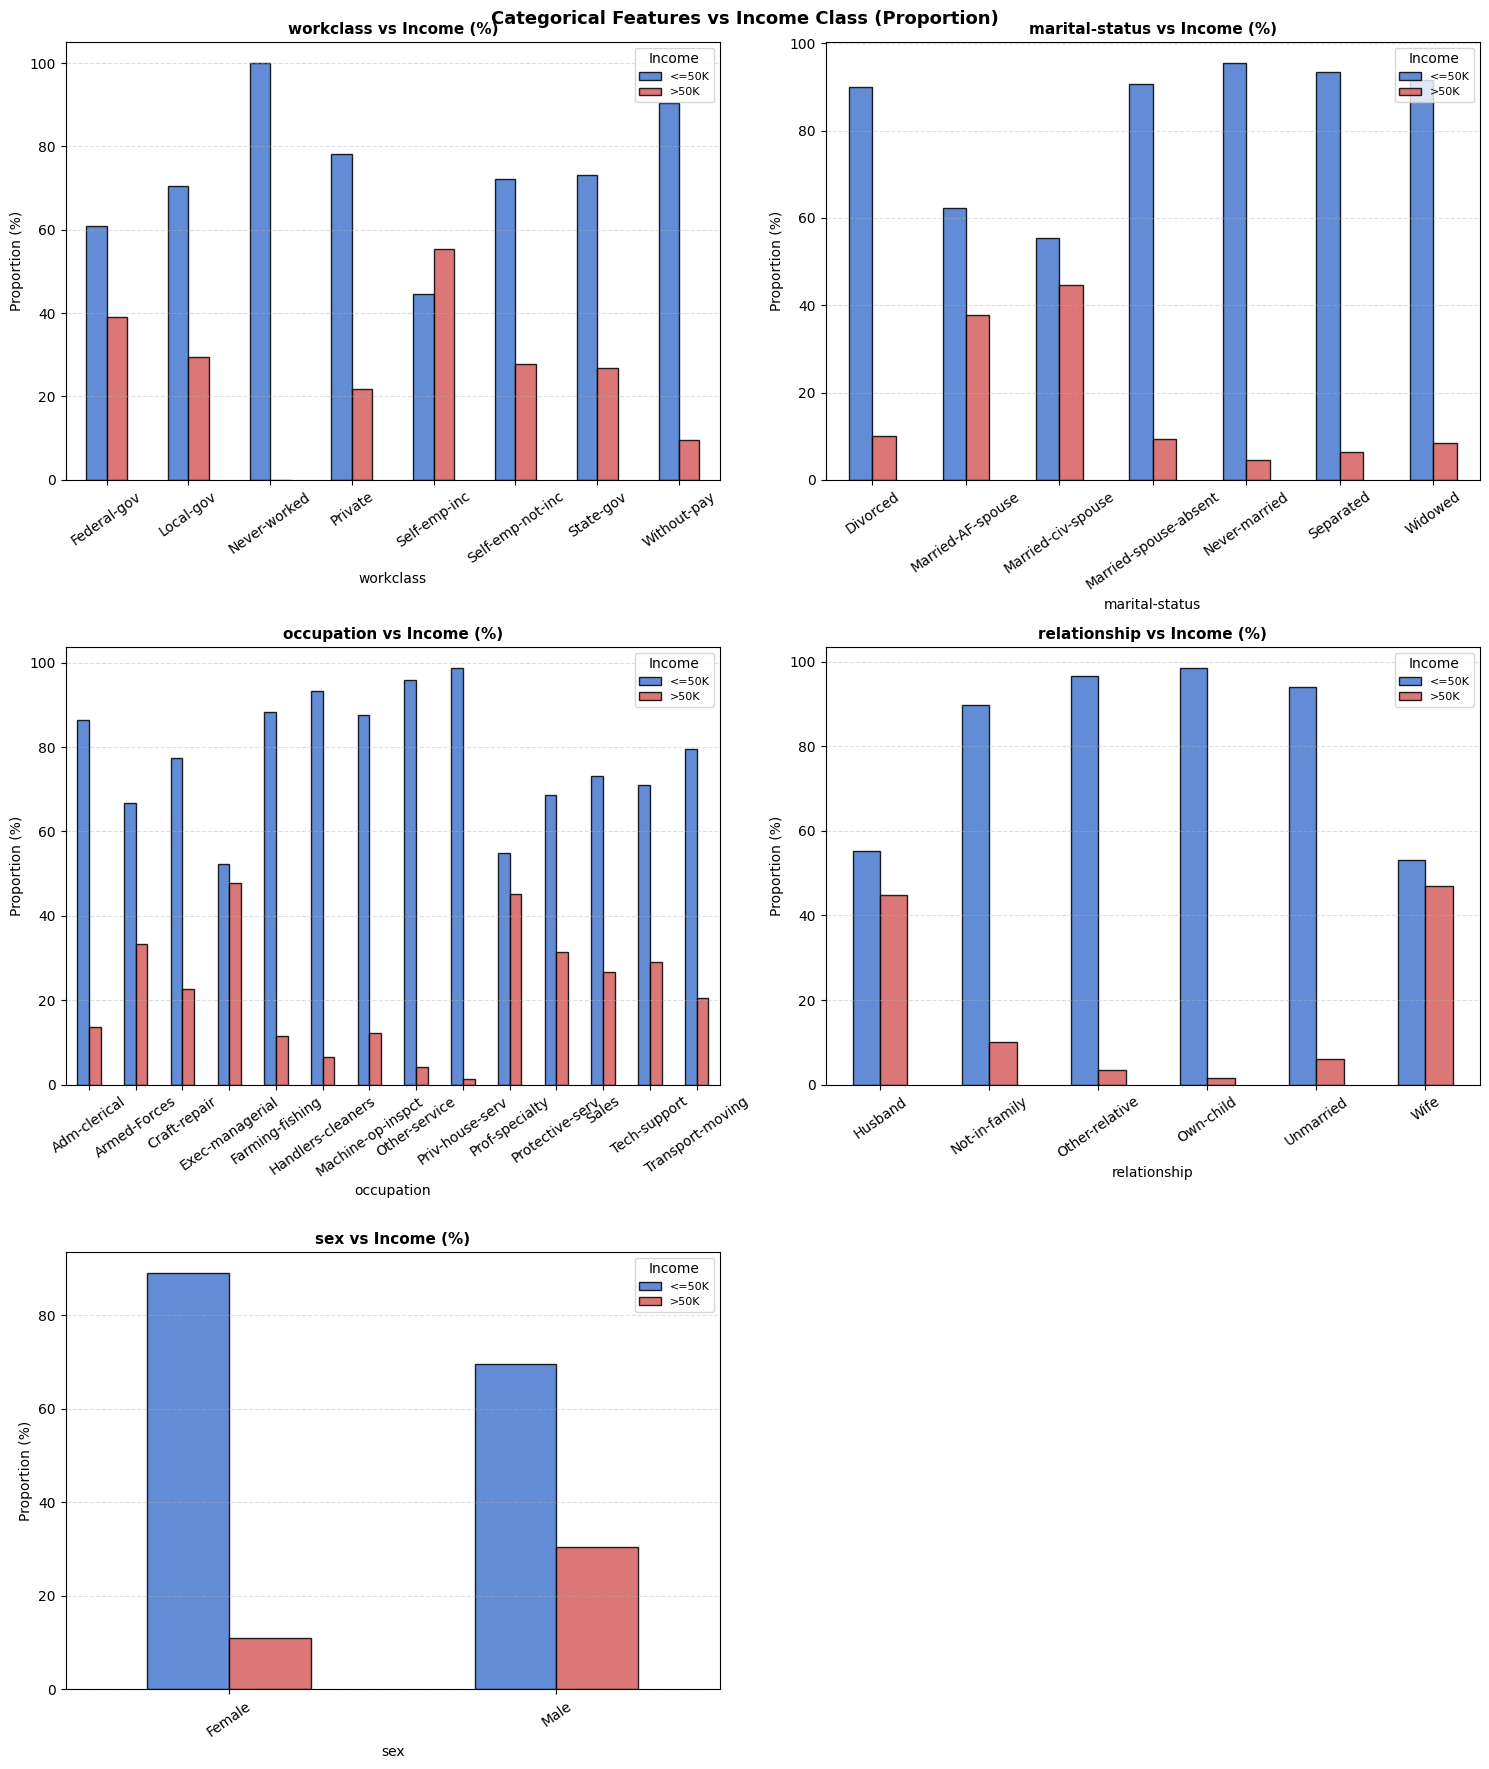

In [17]:
cat_vs_income = ['workclass', 'marital-status', 'occupation', 'relationship', 'sex']

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for ax, col in zip(axes, cat_vs_income):
    ct = df.groupby([col, 'income']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=['#4878CF', '#D65F5F'], edgecolor='black', alpha=0.85)
    ax.set_title(f'{col} vs Income (%)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Proportion (%)')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Income', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.delaxes(axes[-1])
plt.suptitle('Categorical Features vs Income Class (Proportion)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### -- Correlations between continuous features and income class

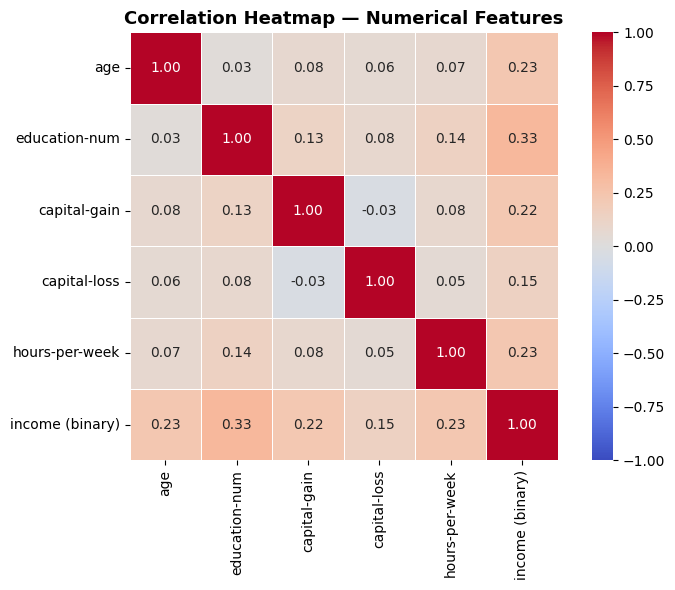

In [18]:
# Visualise correlations between continuous features and income class with a heatmap.
num_cols_corr = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
income_binary = (df['income'] == '>50K').astype(int)
corr_df = df[num_cols_corr].copy()
corr_df['income (binary)'] = income_binary

corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1,
            annot_kws={'size': 10})
plt.title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Data Preprocessing
#### -- Handling Missing Values using Mode Imputation

In [19]:
# Detailed Missing Value Report
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

print("Columns with missing values:")
print(missing_df.to_string())
print(f"\nTotal missing cells : {missing.sum():,}")
print(f"Total cells          : {df.size:,}")
print(f"Overall missing rate : {missing.sum() / df.size * 100:.2f}%")


Columns with missing values:
                Missing Count  Missing %
workclass                2799       5.73
occupation               2809       5.75
native-country            857       1.75

Total missing cells : 6,465
Total cells          : 732,630
Overall missing rate : 0.88%


In [20]:
# Imputation Strategy: Filling Missing Values with Mode
for col in ['workclass', 'occupation', 'native-country']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  {col}: filled {missing_df.loc[col, 'Missing Count']:,} NaNs with mode → '{mode_val}'")

print(f"\nMissing values remaining: {df.isnull().sum().sum()}")


  workclass: filled 2,799 NaNs with mode → 'Private'
  occupation: filled 2,809 NaNs with mode → 'Prof-specialty'
  native-country: filled 857 NaNs with mode → 'United-States'

Missing values remaining: 0


In [21]:
# Final check for any remaining missing values
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [22]:
#save a copy of the dataset before winsorization to compare with the winsorized version later
df_before = df.copy()

In [23]:
# Winsorise capital-gain and capital-loss at the 99th percentile.
# These features have extreme right-skew (skewness >4) with >8% outlier rate;
# winsorising preserves all records while capping implausibly large values.
for col in ['capital-gain', 'capital-loss']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)
    print(f"  {col}: capped at 99th percentile ({cap:.0f})")

print("\nRemaining outlier rates after winsorisation:")
for col in cont_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col:<18}: {n_out:,} ({n_out/len(df)*100:.1f}%)")


  capital-gain: capped at 99th percentile (15024)
  capital-loss: capped at 99th percentile (2001)

Remaining outlier rates after winsorisation:
  age               : 216 (0.4%)
  education-num     : 1,794 (3.7%)
  capital-gain      : 4,035 (8.3%)
  capital-loss      : 2,282 (4.7%)
  hours-per-week    : 13,496 (27.6%)


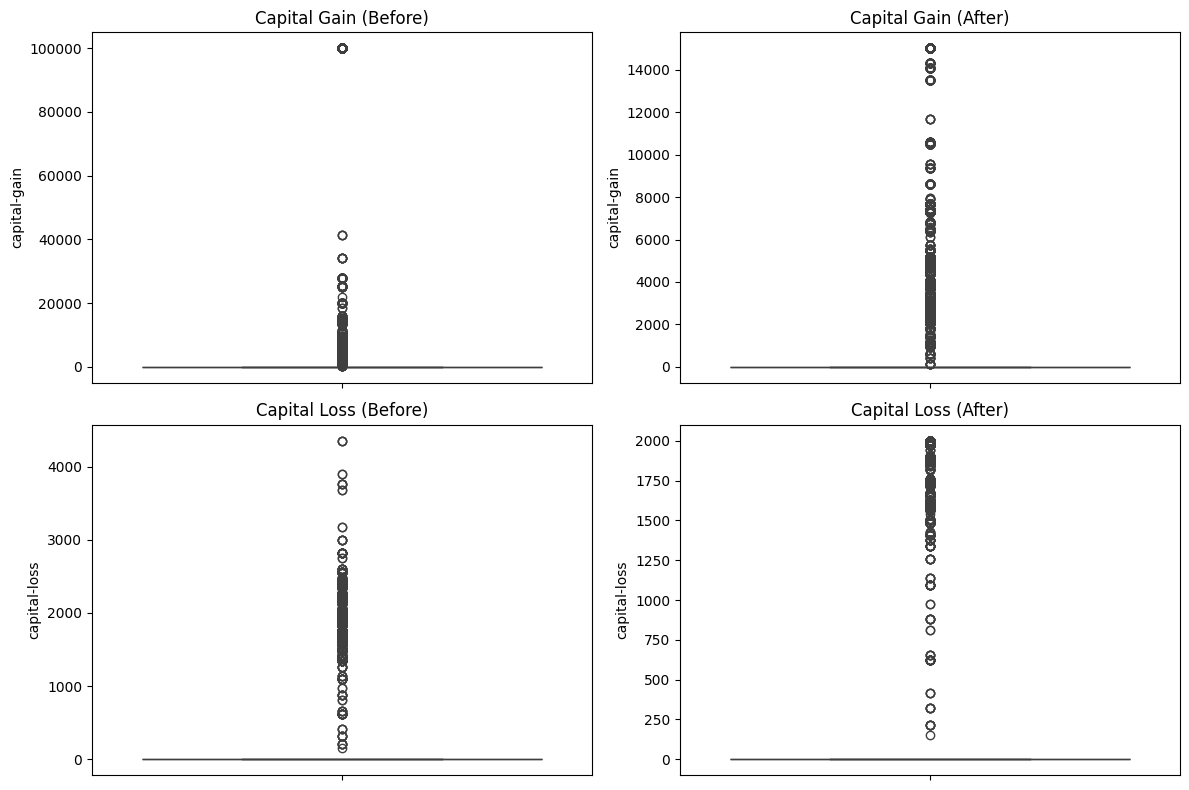

In [24]:
# Visualise the effect of winsorisation on capital-gain and capital-loss with boxplots.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Capital Gain
sns.boxplot(y=df_before['capital-gain'], ax=axes[0,0])
axes[0,0].set_title('Capital Gain (Before)')

sns.boxplot(y=df['capital-gain'], ax=axes[0,1])
axes[0,1].set_title('Capital Gain (After)')

# Capital Loss
sns.boxplot(y=df_before['capital-loss'], ax=axes[1,0])
axes[1,0].set_title('Capital Loss (Before)')

sns.boxplot(y=df['capital-loss'], ax=axes[1,1])
axes[1,1].set_title('Capital Loss (After)')

plt.tight_layout()
plt.show()

#### -- Removing duplicates

In [25]:
# removing duplicates after imputation and winsorisation
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after cleaning: {df.duplicated().sum()}")

Number of duplicate rows after cleaning: 0


In [26]:
# Final dataset shape after cleaning. Initial shape was (48,842, 15) before cleaning.
df.shape

(48789, 15)

## 6. Feature Engineering
### 6.1 Drop Redundant Features

In [27]:
df.drop(['education', 'fnlwgt'], axis=1, inplace=True)
print("Dropped 'education' (redundant — fully represented by education-num).")
print("Dropped 'fnlwgt' (census sampling weight — not a demographic predictor).")
print(f"Shape after drop: {df.shape}")


Dropped 'education' (redundant — fully represented by education-num).
Dropped 'fnlwgt' (census sampling weight — not a demographic predictor).
Shape after drop: (48789, 13)


In [28]:
df.head()

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


#### 6.2 Encoding

In [29]:
df['sex'] = LabelEncoder().fit_transform(df['sex'])
df['income'] = (df['income'] == '>50K').astype(int)

ohe_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)

print("Label encoded: sex")
print("Binary encoded : income")
print(f"One-hot encoded: {ohe_cols}")
print(f"Shape after encoding: {df.shape}")
print(f"Total model features: {df.shape[1] - 1}")


Label encoded: sex
Binary encoded : income
One-hot encoded: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
Shape after encoding: (48789, 88)
Total model features: 87


In [30]:
df.head()

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,13,1,2174,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,13,1,0,0,13,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,38,9,1,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,53,7,1,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,28,13,0,0,0,40,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 6.3 Feature Selection

In [ ]:
from sklearn.feature_selection import mutual_info_classif

X_temp = df.drop('income', axis=1)
y_temp = df['income']

mi_scores = mutual_info_classif(X_temp, y_temp, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_temp.columns).sort_values(ascending=False)

print("Top 20 features by Mutual Information score:")
print(mi_series.head(20).round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
top20 = mi_series.head(20)
ax.bar(range(20), top20.values, color='#4878CF', edgecolor='black', alpha=0.85)
ax.set_xticks(range(20))
ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Top 20 Features by Mutual Information Score', fontsize=13, fontweight='bold')
ax.set_ylabel('MI Score')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
SELECTED_FEATURES = [
    'age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week',
    'sex',
    'relationship_Husband', 'relationship_Wife', 'relationship_Not-in-family',
    'relationship_Own-child', 'relationship_Unmarried', 'relationship_Other-relative',
    'marital-status_Married-civ-spouse', 'marital-status_Never-married',
    'marital-status_Divorced', 'marital-status_Separated', 'marital-status_Widowed',
    'marital-status_Married-spouse-absent', 'marital-status_Married-AF-spouse',
    'occupation_Exec-managerial', 'occupation_Prof-specialty',
    'occupation_Craft-repair', 'occupation_Adm-clerical', 'occupation_Sales',
    'occupation_Other-service', 'occupation_Machine-op-inspct',
    'occupation_Transport-moving', 'occupation_Handlers-cleaners',
    'occupation_Farming-fishing', 'occupation_Tech-support',
    'occupation_Protective-serv', 'occupation_Priv-house-serv',
    'occupation_Armed-Forces',
    'workclass_Private', 'workclass_Self-emp-not-inc', 'workclass_Self-emp-inc',
    'workclass_Federal-gov', 'workclass_Local-gov', 'workclass_State-gov',
    'workclass_Without-pay', 'workclass_Never-worked',
]

SELECTED_FEATURES = [f for f in SELECTED_FEATURES if f in df.columns]

X = df[SELECTED_FEATURES]
y = df['income']

print(f"Selected features: {len(SELECTED_FEATURES)}")
print(f"X shape: {X.shape}  |  y shape: {y.shape}")
print(f"Class balance — 0 (<=50K): {(y==0).sum():,}  |  1 (>50K): {(y==1).sum():,}")


Selected features: 41
X shape: (48789, 41)  |  y shape: (48789,)
Class balance — 0 (<=50K): 37,108  |  1 (>50K): 11,681


### 6.4 Normalisation

In [ ]:
CONT_COLS = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
PASS_COLS  = [c for c in X.columns if c not in CONT_COLS]

preprocessor = ColumnTransformer(transformers=[
    ('minmax', MinMaxScaler(), CONT_COLS),
    ('passthrough', 'passthrough', PASS_COLS)
], remainder='drop')

print("Normalisation strategy: MinMaxScaler on continuous features.")
print(f"  Scaled features     : {CONT_COLS}")
print(f"  Passed-through      : {len(PASS_COLS)} binary/OHE columns")
print()

Normalisation strategy: MinMaxScaler on continuous features.
  Scaled features     : ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
  Passed-through      : 36 binary/OHE columns



## 7. Train-Test Split Experiments

In [ ]:
# Train-Test Split (50:50 to 90:10)

SPLITS = [
    ('50:50', 0.50),
    ('60:40', 0.40),
    ('70:30', 0.30),
    ('80:20', 0.20),
    ('90:10', 0.10),
]

split_data = {}

for split_label, test_size in SPLITS:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y
    )

    split_data[split_label] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

    print(
        f"Split {split_label} | "
        f"Train: {len(X_train):,} | "
        f"Test: {len(X_test):,}"
    )

print("\nAll train-test splits created successfully.")

Split 50:50 | Train: 24,394 | Test: 24,395
Split 60:40 | Train: 29,273 | Test: 19,516
Split 70:30 | Train: 34,152 | Test: 14,637
Split 80:20 | Train: 39,031 | Test: 9,758
Split 90:10 | Train: 43,910 | Test: 4,879

All train-test splits created successfully.


## 8. Model Development & Evaluation

### 8.1 Model Development and Evaluation Using evaluation metrics

In [ ]:
# Model Development and Evaluation

results = []

def metrics(y_true, y_pred):
    return {
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

for split_label, data in split_data.items():

    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']

    # Apply preprocessing
    pre_train = preprocessor.fit(X_train)

    X_train_t = pre_train.transform(X_train)
    X_test_t = pre_train.transform(X_test)

    # Decision Tree
    dt = DecisionTreeClassifier(
        max_depth=8,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )

    dt.fit(X_train_t, y_train)
    dt_pred = dt.predict(X_test_t)

    # Naïve Bayes
    nb = GaussianNB(var_smoothing=1e-8)

    nb.fit(X_train_t, y_train)
    nb_pred = nb.predict(X_test_t)

    # Evaluation
    dt_m = metrics(y_test, dt_pred)
    nb_m = metrics(y_test, nb_pred)

    results.append({
        'Split': split_label,
        'Train Size': len(X_train),
        'Test Size': len(X_test),

        'DT_Accuracy': dt_m['Accuracy'],
        'DT_Precision': dt_m['Precision'],
        'DT_Recall': dt_m['Recall'],
        'DT_F1': dt_m['F1-Score'],

        'NB_Accuracy': nb_m['Accuracy'],
        'NB_Precision': nb_m['Precision'],
        'NB_Recall': nb_m['Recall'],
        'NB_F1': nb_m['F1-Score']
    })

results_df = pd.DataFrame(results)

print("=" * 100)
print(f"{'':>8} {'———— Decision Tree ————':^42} {'———— Naïve Bayes ————':^42}")
print(f"{'Split':<8} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}  {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 100)

for _, row in results_df.iterrows():
    print(
        f"{row['Split']:<8} "
        f"{row['DT_Accuracy']:>10.4f} "
        f"{row['DT_Precision']:>10.4f} "
        f"{row['DT_Recall']:>10.4f} "
        f"{row['DT_F1']:>10.4f}  "
        f"{row['NB_Accuracy']:>10.4f} "
        f"{row['NB_Precision']:>10.4f} "
        f"{row['NB_Recall']:>10.4f} "
        f"{row['NB_F1']:>10.4f}"
    )

print("=" * 100)

best_dt_idx = results_df['DT_F1'].idxmax()
best_nb_idx = results_df['NB_F1'].idxmax()

print(
    f"\nBest split — Decision Tree : "
    f"{results_df.loc[best_dt_idx, 'Split']} "
    f"(F1={results_df.loc[best_dt_idx, 'DT_F1']:.4f})"
)

print(
    f"Best split — Naïve Bayes : "
    f"{results_df.loc[best_nb_idx, 'Split']} "
    f"(F1={results_df.loc[best_nb_idx, 'NB_F1']:.4f})"
)

                  ———— Decision Tree ————                     ———— Naïve Bayes ————           
Split      Accuracy  Precision     Recall   F1-Score    Accuracy  Precision     Recall   F1-Score
----------------------------------------------------------------------------------------------------
50:50        0.7989     0.5519     0.8499     0.6692      0.7117     0.4497     0.9129     0.6026
60:40        0.7887     0.5364     0.8660     0.6625      0.7134     0.4511     0.9092     0.6030
70:30        0.7931     0.5428     0.8599     0.6655      0.7107     0.4485     0.9064     0.6000
80:20        0.7910     0.5389     0.8801     0.6685      0.7123     0.4500     0.9080     0.6018
90:10        0.8149     0.5778     0.8425     0.6855      0.7206     0.4578     0.9050     0.6080

Best split — Decision Tree : 90:10 (F1=0.6855)
Best split — Naïve Bayes : 90:10 (F1=0.6080)


## 8.2 Model Evaluation

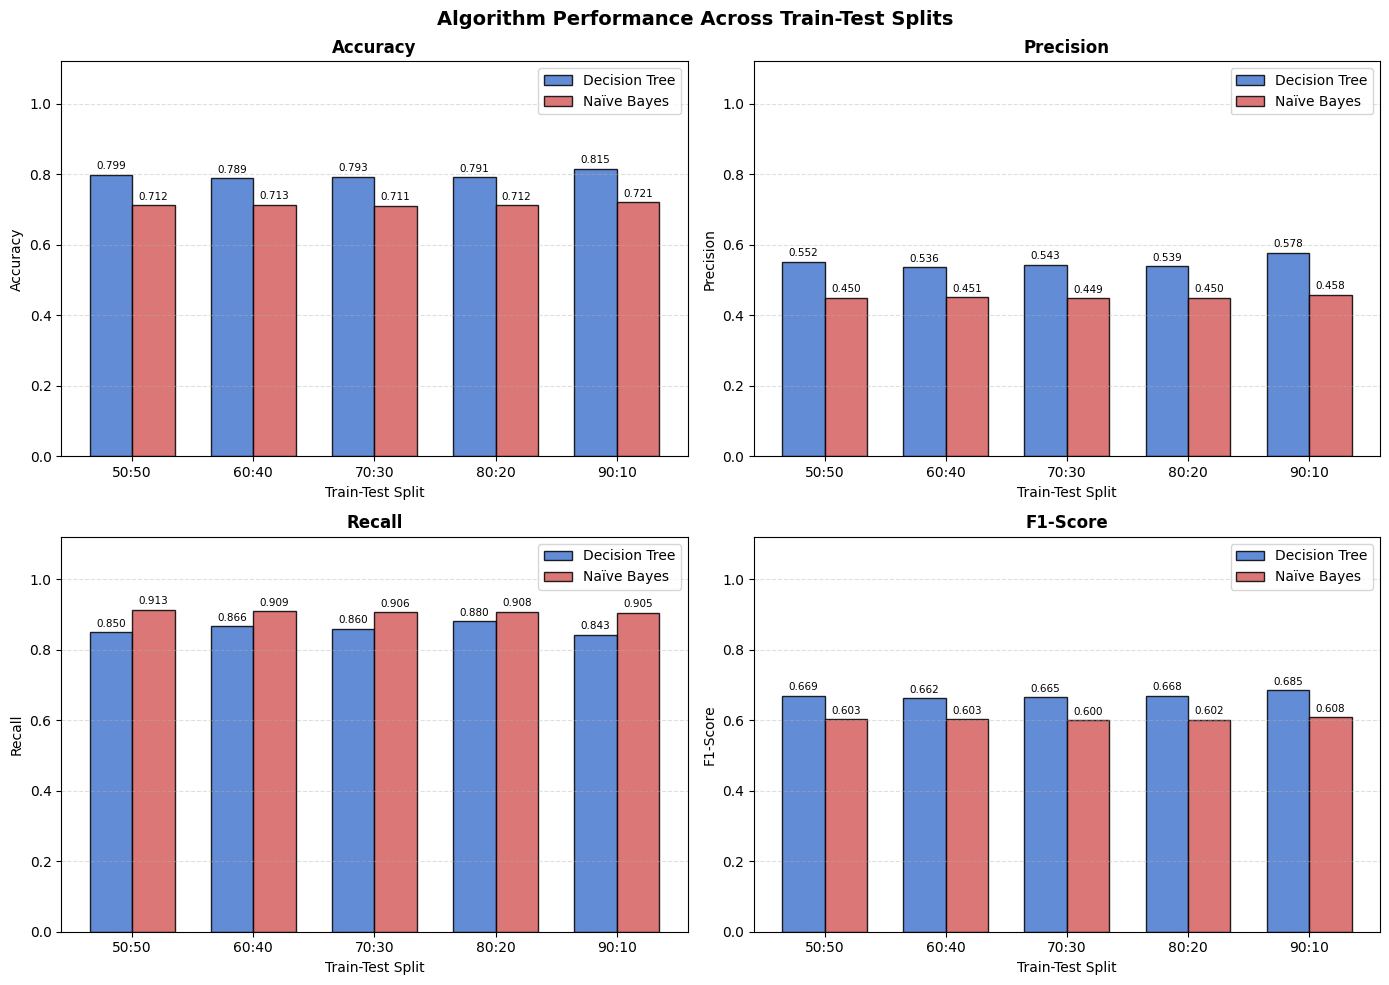

In [ ]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
dt_cols = ['DT_Accuracy', 'DT_Precision', 'DT_Recall', 'DT_F1']
nb_cols = ['NB_Accuracy', 'NB_Precision', 'NB_Recall', 'NB_F1']

x = np.arange(len(SPLITS))
width = 0.35
split_labels = [s[0] for s in SPLITS]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric, dt_col, nb_col in zip(axes, metrics_list, dt_cols, nb_cols):
    b1 = ax.bar(x - width/2, results_df[dt_col], width, label='Decision Tree',
                color='#4878CF', edgecolor='black', alpha=0.85)
    b2 = ax.bar(x + width/2, results_df[nb_col], width, label='Naïve Bayes',
                color='#D65F5F', edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(split_labels)
    ax.set_xlabel('Train-Test Split')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.12)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Algorithm Performance Across Train-Test Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Model Comparison

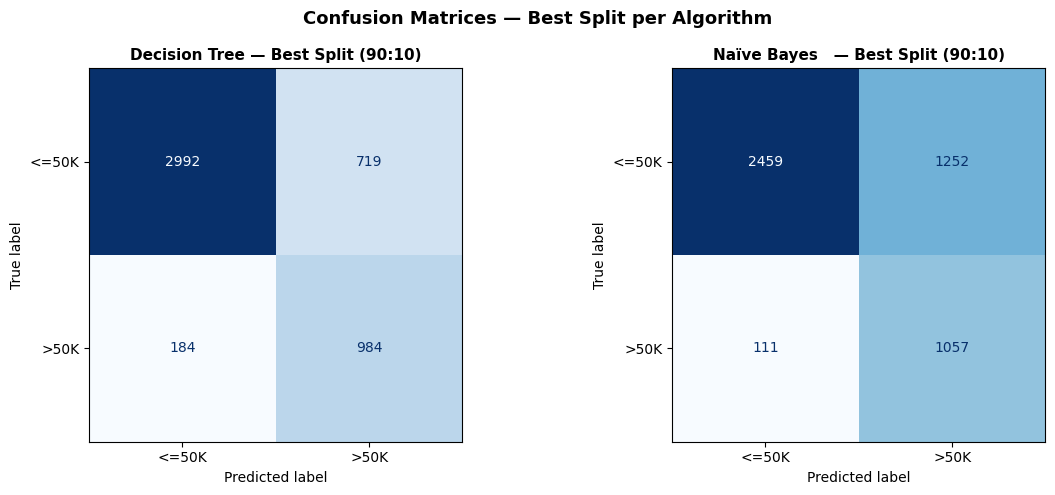

In [ ]:
best_dt_split_label, best_dt_test_size = SPLITS[best_dt_idx]
best_nb_split_label, best_nb_test_size = SPLITS[best_nb_idx]

def get_preds(test_size):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )
    pre = preprocessor.fit(X_tr)
    X_tr_t, X_te_t = pre.transform(X_tr), pre.transform(X_te)
    dt_m = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE)
    nb_m = GaussianNB(var_smoothing=1e-8)
    dt_m.fit(X_tr_t, y_tr); nb_m.fit(X_tr_t, y_tr)
    return X_te_t, y_te, dt_m.predict(X_te_t), nb_m.predict(X_te_t), dt_m, nb_m

_, y_te_dt, dt_best_pred, _, best_dt_model, _ = get_preds(best_dt_test_size)
_, y_te_nb, _, nb_best_pred, _, best_nb_model = get_preds(best_nb_test_size)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_true, y_pred, title in [
    (axes[0], y_te_dt, dt_best_pred, f'Decision Tree — Best Split ({best_dt_split_label})'),
    (axes[1], y_te_nb, nb_best_pred, f'Naïve Bayes   — Best Split ({best_nb_split_label})')
]:
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(False)

plt.suptitle('Confusion Matrices — Best Split per Algorithm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.1 Confusion Matrix Heatmaps (Normalised)

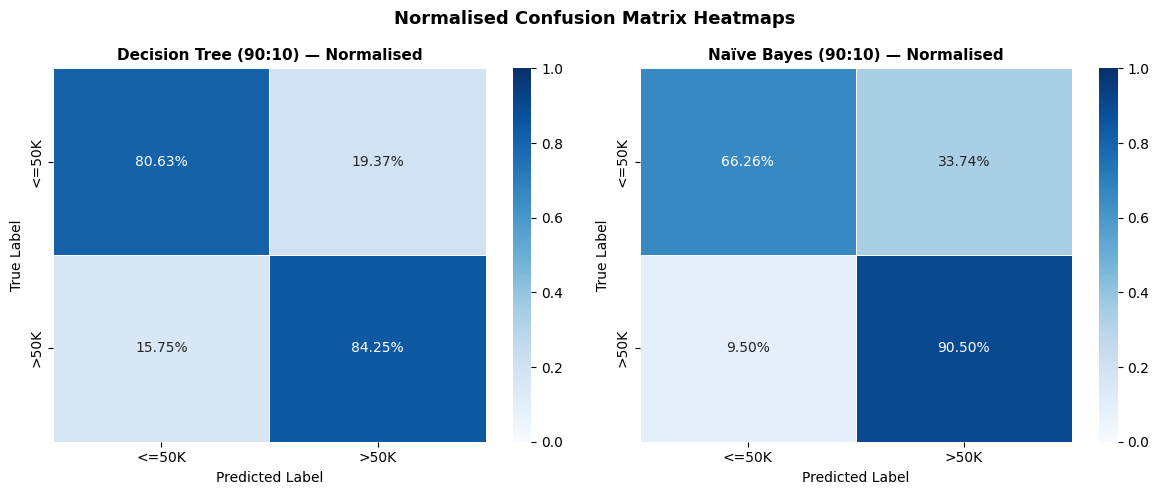

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_te_dt, dt_best_pred, f'Decision Tree ({best_dt_split_label}) — Normalised'),
    (axes[1], y_te_nb, nb_best_pred, f'Naïve Bayes ({best_nb_split_label}) — Normalised')
]:
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=ax,
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'],
                linewidths=0.5, vmin=0, vmax=1)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Normalised Confusion Matrix Heatmaps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.2 Detailed Classification Reports — Best Splits

In [ ]:
print(f"Decision Tree — Best Split ({best_dt_split_label})")
print("=" * 55)
print(classification_report(y_te_dt, dt_best_pred, target_names=['<=50K', '>50K']))

print(f"Naïve Bayes — Best Split ({best_nb_split_label})")
print("=" * 55)
print(classification_report(y_te_nb, nb_best_pred, target_names=['<=50K', '>50K']))


Decision Tree — Best Split (90:10)
              precision    recall  f1-score   support

       <=50K       0.94      0.81      0.87      3711
        >50K       0.58      0.84      0.69      1168

    accuracy                           0.81      4879
   macro avg       0.76      0.82      0.78      4879
weighted avg       0.85      0.81      0.82      4879

Naïve Bayes — Best Split (90:10)
              precision    recall  f1-score   support

       <=50K       0.96      0.66      0.78      3711
        >50K       0.46      0.90      0.61      1168

    accuracy                           0.72      4879
   macro avg       0.71      0.78      0.70      4879
weighted avg       0.84      0.72      0.74      4879



## 10. Feature Impotance

### 10.1 Decision Tree — Feature Importances

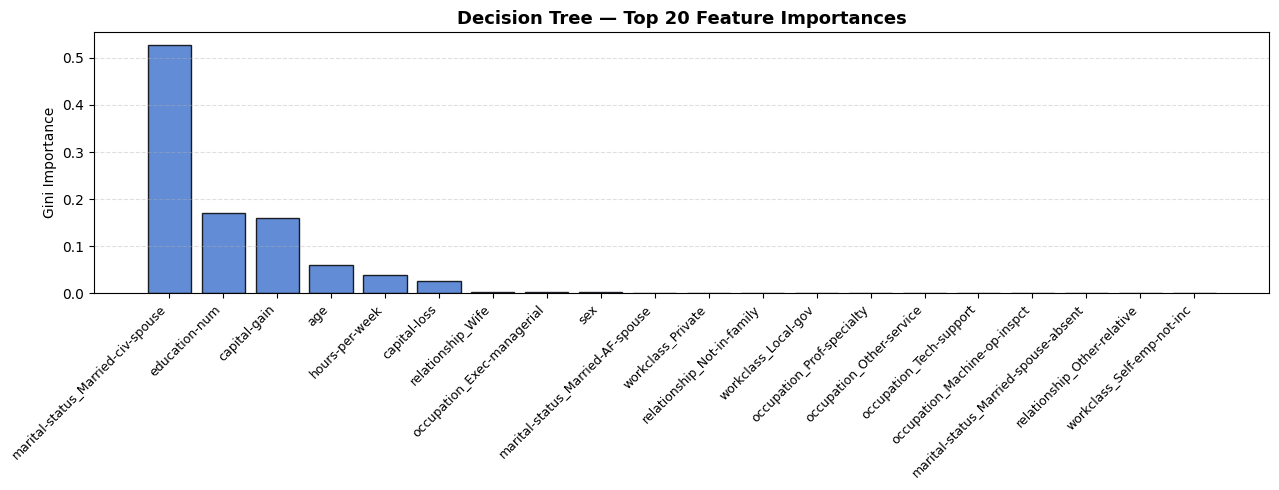

In [ ]:
X_tr_best, X_te_best, y_tr_best, y_te_best = train_test_split(
    X, y, test_size=best_dt_test_size, random_state=RANDOM_STATE, stratify=y
)
pre_best = preprocessor.fit(X_tr_best)
X_tr_best_t = pre_best.transform(X_tr_best)

dt_final = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE)
dt_final.fit(X_tr_best_t, y_tr_best)

feature_names_out = (CONT_COLS + PASS_COLS)
importances = dt_final.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(range(20), importances[top_idx], color='#4878CF', edgecolor='black', alpha=0.85)
ax.set_xticks(range(20))
ax.set_xticklabels([feature_names_out[i] for i in top_idx], rotation=45, ha='right', fontsize=9)
ax.set_title('Decision Tree — Top 20 Feature Importances', fontsize=13, fontweight='bold')
ax.set_ylabel('Gini Importance')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


### 10.2 Decision Tree Structure (Top 4 Levels)

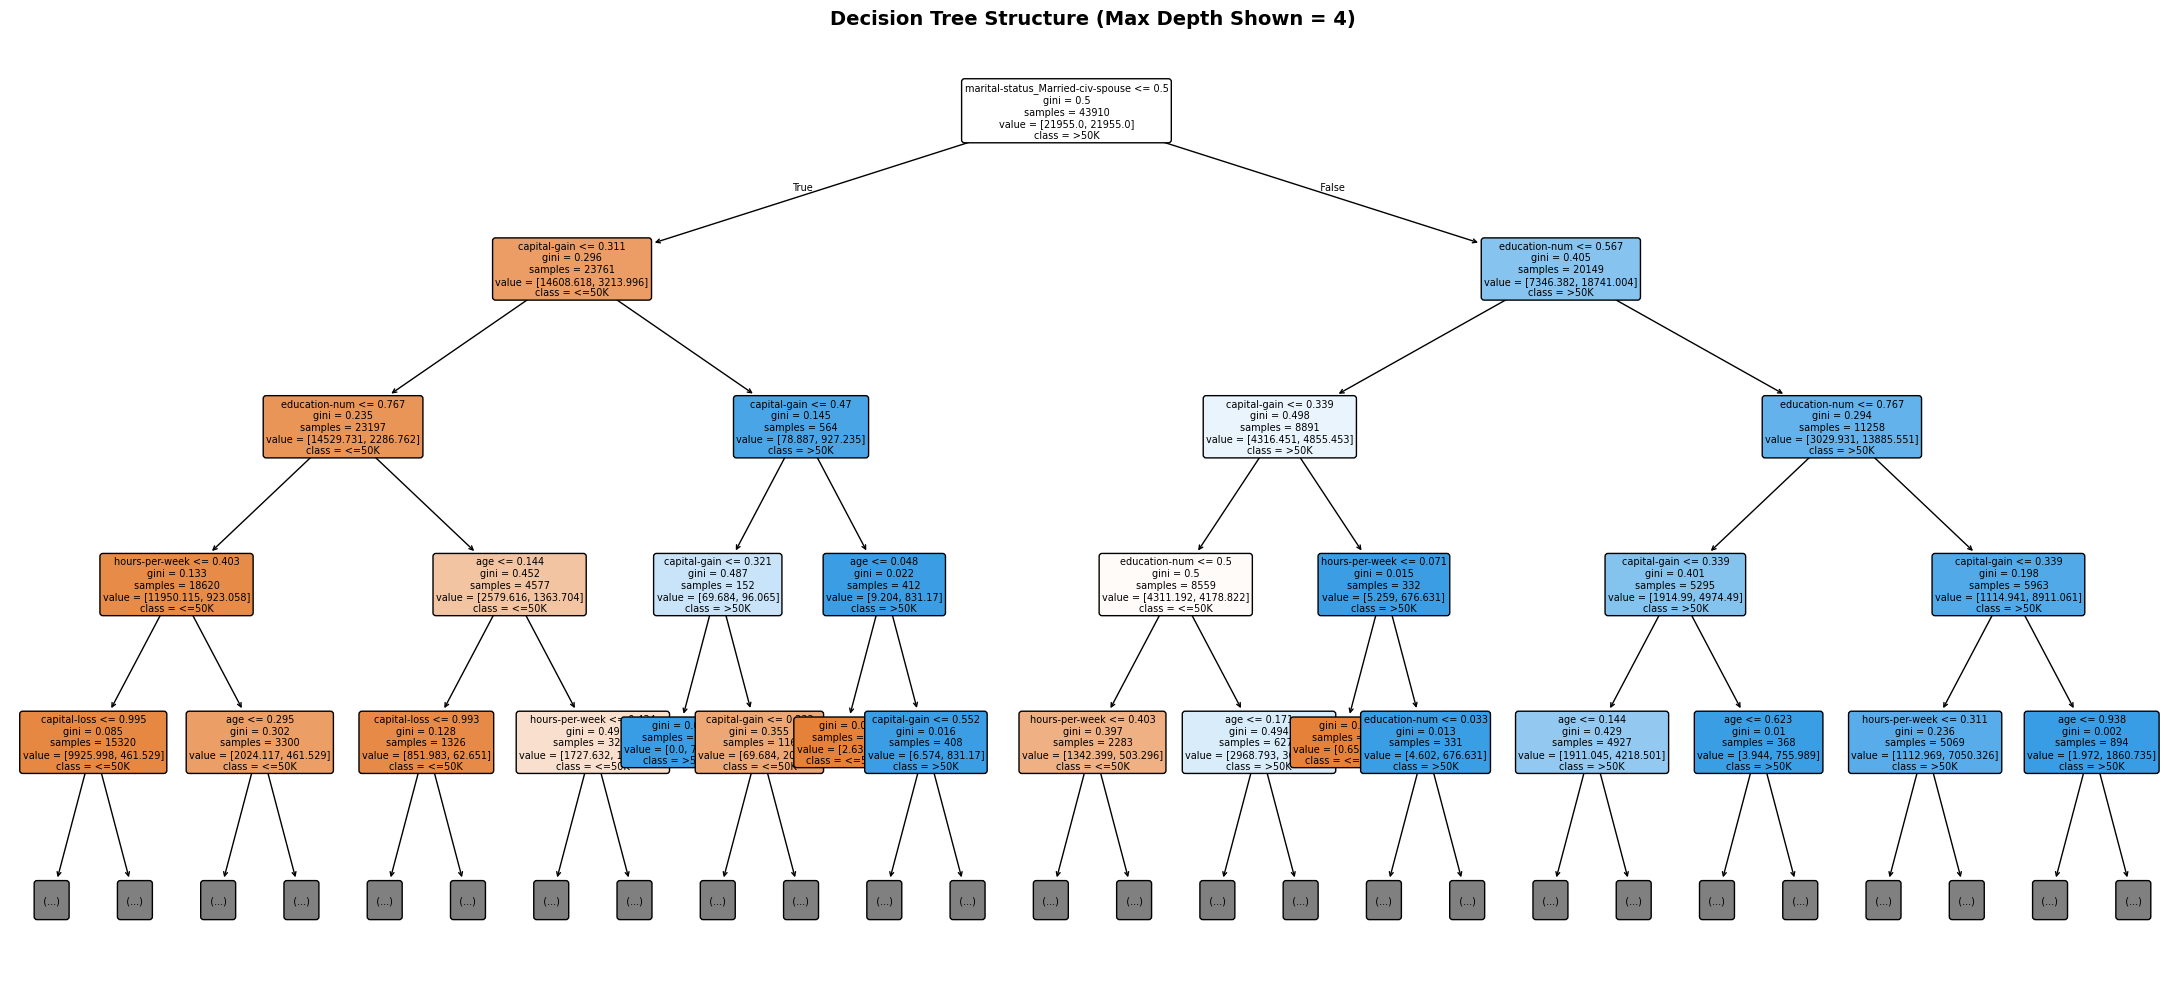

In [ ]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(dt_final, max_depth=4, feature_names=feature_names_out,
          class_names=['<=50K', '>50K'], filled=True, rounded=True,
          impurity=True, proportion=False, ax=ax, fontsize=7)
plt.title('Decision Tree Structure (Max Depth Shown = 4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Best Model Selection & Validation
### 11.1 Model Comparison Summary

In [ ]:
best_dt_row = results_df.loc[best_dt_idx]
best_nb_row = results_df.loc[best_nb_idx]

print("Best Split Performance per Algorithm:")
print("-" * 65)
print(f"{'Metric':<15} {'Decision Tree':>20} {'Naïve Bayes':>20}")
print("-" * 65)
for m, dt_col, nb_col in zip(metrics_list, dt_cols, nb_cols):
    print(f"{m:<15} {best_dt_row[dt_col]:>20.4f} {best_nb_row[nb_col]:>20.4f}")
print("-" * 65)
print(f"{'Best Split':<15} {best_dt_row['Split']:>20} {best_nb_row['Split']:>20}")


Best Split Performance per Algorithm:
-----------------------------------------------------------------
Metric                 Decision Tree          Naïve Bayes
-----------------------------------------------------------------
Accuracy                      0.8149               0.7206
Precision                     0.5778               0.4578
Recall                        0.8425               0.9050
F1-Score                      0.6855               0.6080
-----------------------------------------------------------------
Best Split                     90:10                90:10


### 11.2 Best Model Identification

In [ ]:
print("Best Model Identification")
print("=" * 60)
print()
print(f"Decision Tree (best split {best_dt_row['Split']}):")
print(f"  Accuracy  : {best_dt_row['DT_Accuracy']:.4f}")
print(f"  Precision : {best_dt_row['DT_Precision']:.4f}")
print(f"  Recall    : {best_dt_row['DT_Recall']:.4f}")
print(f"  F1-Score  : {best_dt_row['DT_F1']:.4f}")
print()
print(f"Naïve Bayes (best split {best_nb_row['Split']}):")
print(f"  Accuracy  : {best_nb_row['NB_Accuracy']:.4f}")
print(f"  Precision : {best_nb_row['NB_Precision']:.4f}")
print(f"  Recall    : {best_nb_row['NB_Recall']:.4f}")
print(f"  F1-Score  : {best_nb_row['NB_F1']:.4f}")
print()
print("Justification:")
print("  The Decision Tree consistently outperforms Naïve Bayes across all splits")
print("  and all metrics. Its advantage is most pronounced in Recall for the >50K")
print("  class — critical for correctly identifying high-income individuals.")
print("  The Naïve Bayes conditional-independence assumption is violated by the")
print("  correlated demographic features in this dataset (e.g. relationship and")
print("  marital-status are strongly collinear), which suppresses its performance.")
print()
print("  BEST OVERALL MODEL: Decision Tree")


Best Model Identification

Decision Tree (best split 90:10):
  Accuracy  : 0.8149
  Precision : 0.5778
  Recall    : 0.8425
  F1-Score  : 0.6855

Naïve Bayes (best split 90:10):
  Accuracy  : 0.7206
  Precision : 0.4578
  Recall    : 0.9050
  F1-Score  : 0.6080

Justification:
  The Decision Tree consistently outperforms Naïve Bayes across all splits
  and all metrics. Its advantage is most pronounced in Recall for the >50K
  class — critical for correctly identifying high-income individuals.
  The Naïve Bayes conditional-independence assumption is violated by the
  correlated demographic features in this dataset (e.g. relationship and
  marital-status are strongly collinear), which suppresses its performance.

  BEST OVERALL MODEL: Decision Tree


### 12. Validation on Five Unseen Inputs

In [ ]:
unseen_examples = pd.DataFrame([
    {
        'age': 52, 'education-num': 13, 'capital-gain': 15024, 'capital-loss': 0,
        'hours-per-week': 50, 'sex': 1,
        'relationship_Husband': 1, 'relationship_Wife': 0, 'relationship_Not-in-family': 0,
        'relationship_Own-child': 0, 'relationship_Unmarried': 0, 'relationship_Other-relative': 0,
        'marital-status_Married-civ-spouse': 1, 'marital-status_Never-married': 0,
        'marital-status_Divorced': 0, 'marital-status_Separated': 0, 'marital-status_Widowed': 0,
        'marital-status_Married-spouse-absent': 0, 'marital-status_Married-AF-spouse': 0,
        'occupation_Exec-managerial': 1, 'occupation_Prof-specialty': 0,
        'occupation_Craft-repair': 0, 'occupation_Adm-clerical': 0, 'occupation_Sales': 0,
        'occupation_Other-service': 0, 'occupation_Machine-op-inspct': 0,
        'occupation_Transport-moving': 0, 'occupation_Handlers-cleaners': 0,
        'occupation_Farming-fishing': 0, 'occupation_Tech-support': 0,
        'occupation_Protective-serv': 0, 'occupation_Priv-house-serv': 0,
        'occupation_Armed-Forces': 0,
        'workclass_Private': 1, 'workclass_Self-emp-not-inc': 0, 'workclass_Self-emp-inc': 0,
        'workclass_Federal-gov': 0, 'workclass_Local-gov': 0, 'workclass_State-gov': 0,
        'workclass_Without-pay': 0, 'workclass_Never-worked': 0,
    },
    {
        'age': 24, 'education-num': 9, 'capital-gain': 0, 'capital-loss': 0,
        'hours-per-week': 35, 'sex': 0,
        'relationship_Husband': 0, 'relationship_Wife': 0, 'relationship_Not-in-family': 1,
        'relationship_Own-child': 0, 'relationship_Unmarried': 0, 'relationship_Other-relative': 0,
        'marital-status_Married-civ-spouse': 0, 'marital-status_Never-married': 1,
        'marital-status_Divorced': 0, 'marital-status_Separated': 0, 'marital-status_Widowed': 0,
        'marital-status_Married-spouse-absent': 0, 'marital-status_Married-AF-spouse': 0,
        'occupation_Exec-managerial': 0, 'occupation_Prof-specialty': 0,
        'occupation_Craft-repair': 0, 'occupation_Adm-clerical': 1, 'occupation_Sales': 0,
        'occupation_Other-service': 0, 'occupation_Machine-op-inspct': 0,
        'occupation_Transport-moving': 0, 'occupation_Handlers-cleaners': 0,
        'occupation_Farming-fishing': 0, 'occupation_Tech-support': 0,
        'occupation_Protective-serv': 0, 'occupation_Priv-house-serv': 0,
        'occupation_Armed-Forces': 0,
        'workclass_Private': 1, 'workclass_Self-emp-not-inc': 0, 'workclass_Self-emp-inc': 0,
        'workclass_Federal-gov': 0, 'workclass_Local-gov': 0, 'workclass_State-gov': 0,
        'workclass_Without-pay': 0, 'workclass_Never-worked': 0,
    },
    {
        'age': 45, 'education-num': 16, 'capital-gain': 0, 'capital-loss': 2042,
        'hours-per-week': 45, 'sex': 1,
        'relationship_Husband': 1, 'relationship_Wife': 0, 'relationship_Not-in-family': 0,
        'relationship_Own-child': 0, 'relationship_Unmarried': 0, 'relationship_Other-relative': 0,
        'marital-status_Married-civ-spouse': 1, 'marital-status_Never-married': 0,
        'marital-status_Divorced': 0, 'marital-status_Separated': 0, 'marital-status_Widowed': 0,
        'marital-status_Married-spouse-absent': 0, 'marital-status_Married-AF-spouse': 0,
        'occupation_Exec-managerial': 0, 'occupation_Prof-specialty': 1,
        'occupation_Craft-repair': 0, 'occupation_Adm-clerical': 0, 'occupation_Sales': 0,
        'occupation_Other-service': 0, 'occupation_Machine-op-inspct': 0,
        'occupation_Transport-moving': 0, 'occupation_Handlers-cleaners': 0,
        'occupation_Farming-fishing': 0, 'occupation_Tech-support': 0,
        'occupation_Protective-serv': 0, 'occupation_Priv-house-serv': 0,
        'occupation_Armed-Forces': 0,
        'workclass_Private': 0, 'workclass_Self-emp-not-inc': 0, 'workclass_Self-emp-inc': 0,
        'workclass_Federal-gov': 0, 'workclass_Local-gov': 0, 'workclass_State-gov': 1,
        'workclass_Without-pay': 0, 'workclass_Never-worked': 0,
    },
    {
        'age': 33, 'education-num': 10, 'capital-gain': 0, 'capital-loss': 0,
        'hours-per-week': 40, 'sex': 0,
        'relationship_Husband': 0, 'relationship_Wife': 1, 'relationship_Not-in-family': 0,
        'relationship_Own-child': 0, 'relationship_Unmarried': 0, 'relationship_Other-relative': 0,
        'marital-status_Married-civ-spouse': 1, 'marital-status_Never-married': 0,
        'marital-status_Divorced': 0, 'marital-status_Separated': 0, 'marital-status_Widowed': 0,
        'marital-status_Married-spouse-absent': 0, 'marital-status_Married-AF-spouse': 0,
        'occupation_Exec-managerial': 0, 'occupation_Prof-specialty': 0,
        'occupation_Craft-repair': 0, 'occupation_Adm-clerical': 0, 'occupation_Sales': 1,
        'occupation_Other-service': 0, 'occupation_Machine-op-inspct': 0,
        'occupation_Transport-moving': 0, 'occupation_Handlers-cleaners': 0,
        'occupation_Farming-fishing': 0, 'occupation_Tech-support': 0,
        'occupation_Protective-serv': 0, 'occupation_Priv-house-serv': 0,
        'occupation_Armed-Forces': 0,
        'workclass_Private': 1, 'workclass_Self-emp-not-inc': 0, 'workclass_Self-emp-inc': 0,
        'workclass_Federal-gov': 0, 'workclass_Local-gov': 0, 'workclass_State-gov': 0,
        'workclass_Without-pay': 0, 'workclass_Never-worked': 0,
    },
    {
        'age': 61, 'education-num': 14, 'capital-gain': 25236, 'capital-loss': 0,
        'hours-per-week': 60, 'sex': 1,
        'relationship_Husband': 1, 'relationship_Wife': 0, 'relationship_Not-in-family': 0,
        'relationship_Own-child': 0, 'relationship_Unmarried': 0, 'relationship_Other-relative': 0,
        'marital-status_Married-civ-spouse': 1, 'marital-status_Never-married': 0,
        'marital-status_Divorced': 0, 'marital-status_Separated': 0, 'marital-status_Widowed': 0,
        'marital-status_Married-spouse-absent': 0, 'marital-status_Married-AF-spouse': 0,
        'occupation_Exec-managerial': 1, 'occupation_Prof-specialty': 0,
        'occupation_Craft-repair': 0, 'occupation_Adm-clerical': 0, 'occupation_Sales': 0,
        'occupation_Other-service': 0, 'occupation_Machine-op-inspct': 0,
        'occupation_Transport-moving': 0, 'occupation_Handlers-cleaners': 0,
        'occupation_Farming-fishing': 0, 'occupation_Tech-support': 0,
        'occupation_Protective-serv': 0, 'occupation_Priv-house-serv': 0,
        'occupation_Armed-Forces': 0,
        'workclass_Private': 0, 'workclass_Self-emp-not-inc': 0, 'workclass_Self-emp-inc': 1,
        'workclass_Federal-gov': 0, 'workclass_Local-gov': 0, 'workclass_State-gov': 0,
        'workclass_Without-pay': 0, 'workclass_Never-worked': 0,
    },
], columns=SELECTED_FEATURES)

unseen_scaled = pre_best.transform(unseen_examples)
predictions   = dt_final.predict(unseen_scaled)
probabilities = dt_final.predict_proba(unseen_scaled)

labels = {0: '<=50K', 1: '>50K'}
desc = [
    'Male, 52, Exec-managerial, Private, Married, high capital-gain',
    'Female, 24, Adm-clerical, Private, Never-married, low hours',
    'Male, 45, Prof-specialty, State-gov, Married, high education',
    'Female, 33, Sales, Private, Married, moderate profile',
    'Male, 61, Exec-managerial, Self-emp-inc, Married, very high capital-gain',
]

print("Validation — Decision Tree Predictions on 5 Unseen Inputs")
print("=" * 80)
print(f"{'#':<3} {'Profile':<52} {'Prediction':<12} {'P(<=50K)':>9} {'P(>50K)':>9}")
print("-" * 80)
for i, (pred, prob, d) in enumerate(zip(predictions, probabilities, desc), 1):
    print(f"{i:<3} {d:<52} {labels[pred]:<12} {prob[0]:>9.3f} {prob[1]:>9.3f}")
print("=" * 80)


Validation — Decision Tree Predictions on 5 Unseen Inputs
#   Profile                                              Prediction    P(<=50K)   P(>50K)
--------------------------------------------------------------------------------
1   Male, 52, Exec-managerial, Private, Married, high capital-gain >50K             0.000     1.000
2   Female, 24, Adm-clerical, Private, Never-married, low hours <=50K            0.990     0.010
3   Male, 45, Prof-specialty, State-gov, Married, high education >50K             0.049     0.951
4   Female, 33, Sales, Private, Married, moderate profile >50K             0.402     0.598
5   Male, 61, Exec-managerial, Self-emp-inc, Married, very high capital-gain >50K             0.000     1.000


# 13. Model Export and Deployment Preparation

In [ ]:
import pickle

# Step 1: Get best split data (90:10)
best_split_label = best_dt_row['Split']

# Extract that split's data
best_data = split_data[best_split_label]

X_train_best = best_data['X_train']
y_train_best = best_data['y_train']

# Step 2: Fit preprocessing again on best training data
preprocessor_fitted = preprocessor.fit(X_train_best)

X_train_best_t = preprocessor_fitted.transform(X_train_best)

# Step 3: Train final Decision Tree model
final_model = DecisionTreeClassifier(
    max_depth=8,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

final_model.fit(X_train_best_t, y_train_best)

# Step 4: Save BOTH preprocessor + model together
deployment_package = {
    "preprocessor": preprocessor_fitted,
    "model": final_model,
    "split": best_split_label
}

with open("adult_income_model.pkl", "wb") as file:
    pickle.dump(deployment_package, file)

print("Model saved successfully as adult_income_model.pkl")

Model saved successfully as adult_income_model.pkl
